In [1]:
import xarray as xr

import warnings

import numpy as np

import scipy.stats as stats

from scipy.stats import pearsonr

import pandas as pd

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

import glob

import datetime

import matplotlib.pyplot as plt

import pickle

import cartopy.crs as ccrs

from sklearn.preprocessing import QuantileTransformer

import cartopy.feature as cfeature

from scipy.stats import spearmanr

from matplotlib.colors import Normalize

import seaborn as sns

import os

import matplotlib.colors as mcolors

from matplotlib.colors import TwoSlopeNorm

from sklearn.metrics import silhouette_score

from scipy.stats import pearsonr

from pathlib import Path

from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

pd.options.mode.chained_assignment = None

In [2]:
## load surface pressure 

sfc_file_path = "/home/annierosen16/data/era5sgp/era5_sl_surface_terms_full_sgp"

files = sorted(glob.glob(f"{sfc_file_path}/*.nc"))

ds0 = xr.open_dataset(files[0])

keep = {"sp"}

drop = [v for v in ds0.data_vars if v not in keep]

ds0.close()

sfc_sp = xr.open_mfdataset(
    
    files,
    
    combine="by_coords",
    
    parallel=False,
    
    drop_variables=drop,
    
    chunks={"time": 24})

sfc_sp = sfc_sp.sel(
    
    latitude=slice(39, 30),
    
    longitude=slice(-105, -95)
)

sfc_sp = sfc_sp.assign_coords(
    
    valid_time=sfc_sp["valid_time"] - pd.Timedelta(hours=6)
)

sp = sfc_sp["sp"]

In [3]:
sp = sp.sel(
    valid_time=(
        (sp.valid_time.dt.year >= 1979) &
        (sp.valid_time.dt.year <= 2025) &
        (sp.valid_time.dt.month.isin([5, 6, 7, 8, 9]))
    )
)

sp_daily = (sp.resample(valid_time="1D").mean().dropna(dim="valid_time", how="all"))

sp_daily = sp_daily.rename({"valid_time": "date"})

# turn DataArray into Dataset with variable name

sp_daily_df = (sp_daily.to_dataset(name="sp_daily").to_dataframe().reset_index())

In [4]:
file_path = '/home/annierosen16/master_1979_2025.pkl'

with open(file_path, 'rb') as f:
    
    master = pickle.load(f)
    
master["date"] = pd.to_datetime(master["date"])

In [5]:
master_w_sp_1979_2025 = master.merge(
    
    sp_daily_df[["date", "latitude", "longitude", "sp_daily"]],
    
    on=["date", "latitude", "longitude"],
    
    how="left"
)

In [6]:
master_w_sp_1979_2025 = master_w_sp_1979_2025.rename(
    
    columns={"sp_daily": "average_sp"})

In [7]:
with open('/home/annierosen16/master_w_sp_1979_2025.pkl', 'wb') as f:
    
    pickle.dump(master_w_sp_1979_2025, f)

In [46]:
# with open('/home/annierosen16/master_w_sp_2001_2025.pkl', 'rb') as f:
    
#     master = pickle.load(f)

In [35]:
# df = master.copy()

# df['date'] = pd.to_datetime(df['date'])

# df['dryape'] = df['dryape'].astype(bool)

# df['wetape'] = df['wetape'].astype(bool)

# df = df.sort_values(['latitude', 'longitude', 'date'])

# g = df.groupby(['latitude', 'longitude'])

# next_date   = g['date'].shift(-1)

# next_is_day = (next_date - df['date']) == pd.Timedelta(days=1)

# next_dry = g['dryape'].shift(-1).fillna(False)

# next_wet = g['wetape'].shift(-1).fillna(False)

# # day-before flags: True today if TOMORROW exists and is an APE

# df['predryape'] = (next_is_day & next_dry).astype(bool)

# df['prewetape'] = (next_is_day & next_wet).astype(bool)

/tmp/ipykernel_57347/1039781508.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  next_dry = g['dryape'].shift(-1).fillna(False)
/tmp/ipykernel_57347/1039781508.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  next_wet = g['wetape'].shift(-1).fillna(False)


In [45]:
# with open('/home/annierosen16/master_w_sp_2001_2025.pkl', 'wb') as f:
    
#     pickle.dump(df, f)

In [5]:
# ## get lag 1 day counts

# df = master.copy()

# df['date'] = pd.to_datetime(df['date'])

# # sort so shifting works correctly

# df = df.sort_values(['latitude', 'longitude', 'date'])

In [7]:
# def classify_regime(row):
    
#     if row['dryape']:
#         return 'Dry APE'
#     elif row['wetape']:
#         return 'Wet APE'
#     elif row['drycoupling']:
#         return 'Dry Coupling'
#     elif row['wetcoupling']:
#         return 'Wet Coupling'
#     else:
#         return 'None'

# df['regime'] = df.apply(classify_regime, axis=1)

In [9]:
# df['regime_lag1'] = (
    
#     df.groupby(['latitude', 'longitude'])['regime']
      
#     .shift(1)
# )

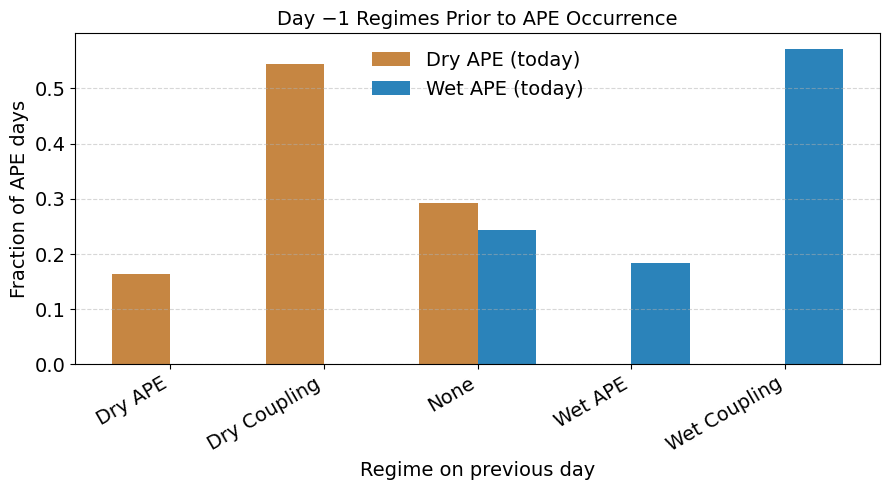

In [13]:
# # --- dry APE today ---
# dry_today = df[df['dryape'] & df['regime_lag1'].notna()]

# dry_frac = (
#     dry_today['regime_lag1']
#     .value_counts(normalize=True)
# )

# # --- wet APE today ---
# wet_today = df[df['wetape'] & df['regime_lag1'].notna()]
# wet_frac = (
#     wet_today['regime_lag1']
#     .value_counts(normalize=True)
# )

# # combine into one table
# lag_df = (
#     pd.concat([dry_frac, wet_frac], axis=1)
#       .fillna(0)
# )

# lag_df.columns = ['Dry APE', 'Wet APE']
# lag_df = lag_df.sort_index()


# FONT = 14

# x = np.arange(len(lag_df))

# width = 0.38

# fig, ax = plt.subplots(figsize=(9,5))

# ax.bar(
#     x - width/2,
#     lag_df['Dry APE'],
#     width,
#     label='Dry APE (today)',
#     color='#c68642'
# )

# ax.bar(
#     x + width/2,
#     lag_df['Wet APE'],
#     width,
#     label='Wet APE (today)',
#     color='#2b83ba'
# )

# ax.set_ylabel('Fraction of APE days', fontsize=FONT)

# ax.set_xlabel('Regime on previous day', fontsize=FONT)

# ax.set_title('Day −1 Regimes Prior to APE Occurrence', fontsize=FONT)

# ax.set_xticks(x)

# ax.set_xticklabels(lag_df.index, rotation=30, ha='right')

# ax.tick_params(labelsize=FONT)

# ax.legend(frameon=False, fontsize=FONT)

# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()
